In [1]:
# **Objective:** Understand the data, identify patterns, and prepare for feature engineering
## Set up

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os  # <-- THÊM DÒNG NÀY


In [2]:
# Create necessary directories for outputs
output_dirs = [
    '../reports/figures',
    '../data/processed',
    '../models',
    '../reports'
]

for directory in output_dirs:
    os.makedirs(directory, exist_ok=True)
    print(f"✅ Created directory: {directory}")

print("\n✅ All required directories are ready!")
print("=" * 80)
# ==============================================================================

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)


✅ Created directory: ../reports/figures
✅ Created directory: ../data/processed
✅ Created directory: ../models
✅ Created directory: ../reports

✅ All required directories are ready!


# Load data

In [3]:
# Load data
df = pd.read_csv('../data/raw/telco_customer_churn.csv')


# Check data quality

In [4]:
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Dataset shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [5]:
# Display first few rows
display(df.head())

# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing Values:")
display(missing_df[missing_df['Missing %'] > 0])

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Missing Values:


,Missing Count,Missing %


In [6]:
# Statistical summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Target distribution

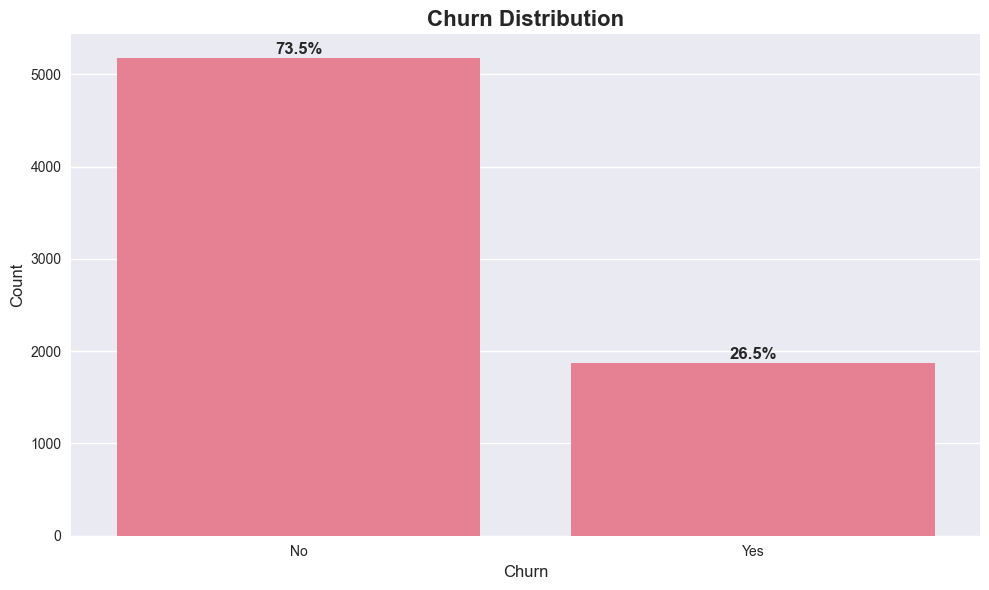

Churn Rate: 26.54%
Retention Rate: 73.46%


C:\Users\caida\AppData\Local\Temp\ipykernel_1860\1316740238.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Churn Rate: {churn_pct[1]:.2f}%")
C:\Users\caida\AppData\Local\Temp\ipykernel_1860\1316740238.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Retention Rate: {churn_pct[0]:.2f}%")


In [7]:
# Target distribution
plt.figure(figsize=(10, 6))
churn_counts = df['Churn'].value_counts()
churn_pct = churn_counts / len(df) * 100

ax = sns.barplot(x=churn_counts.index, y=churn_counts.values)
plt.title('Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add percentage labels
for i, (count, pct) in enumerate(zip(churn_counts.values, churn_pct.values)):
    ax.text(i, count + 50, f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Churn Rate: {churn_pct[1]:.2f}%")
print(f"Retention Rate: {churn_pct[0]:.2f}%")


# Demographic analysis

C:\Users\caida\AppData\Local\Temp\ipykernel_1860\4038556610.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(['No', 'Yes'])


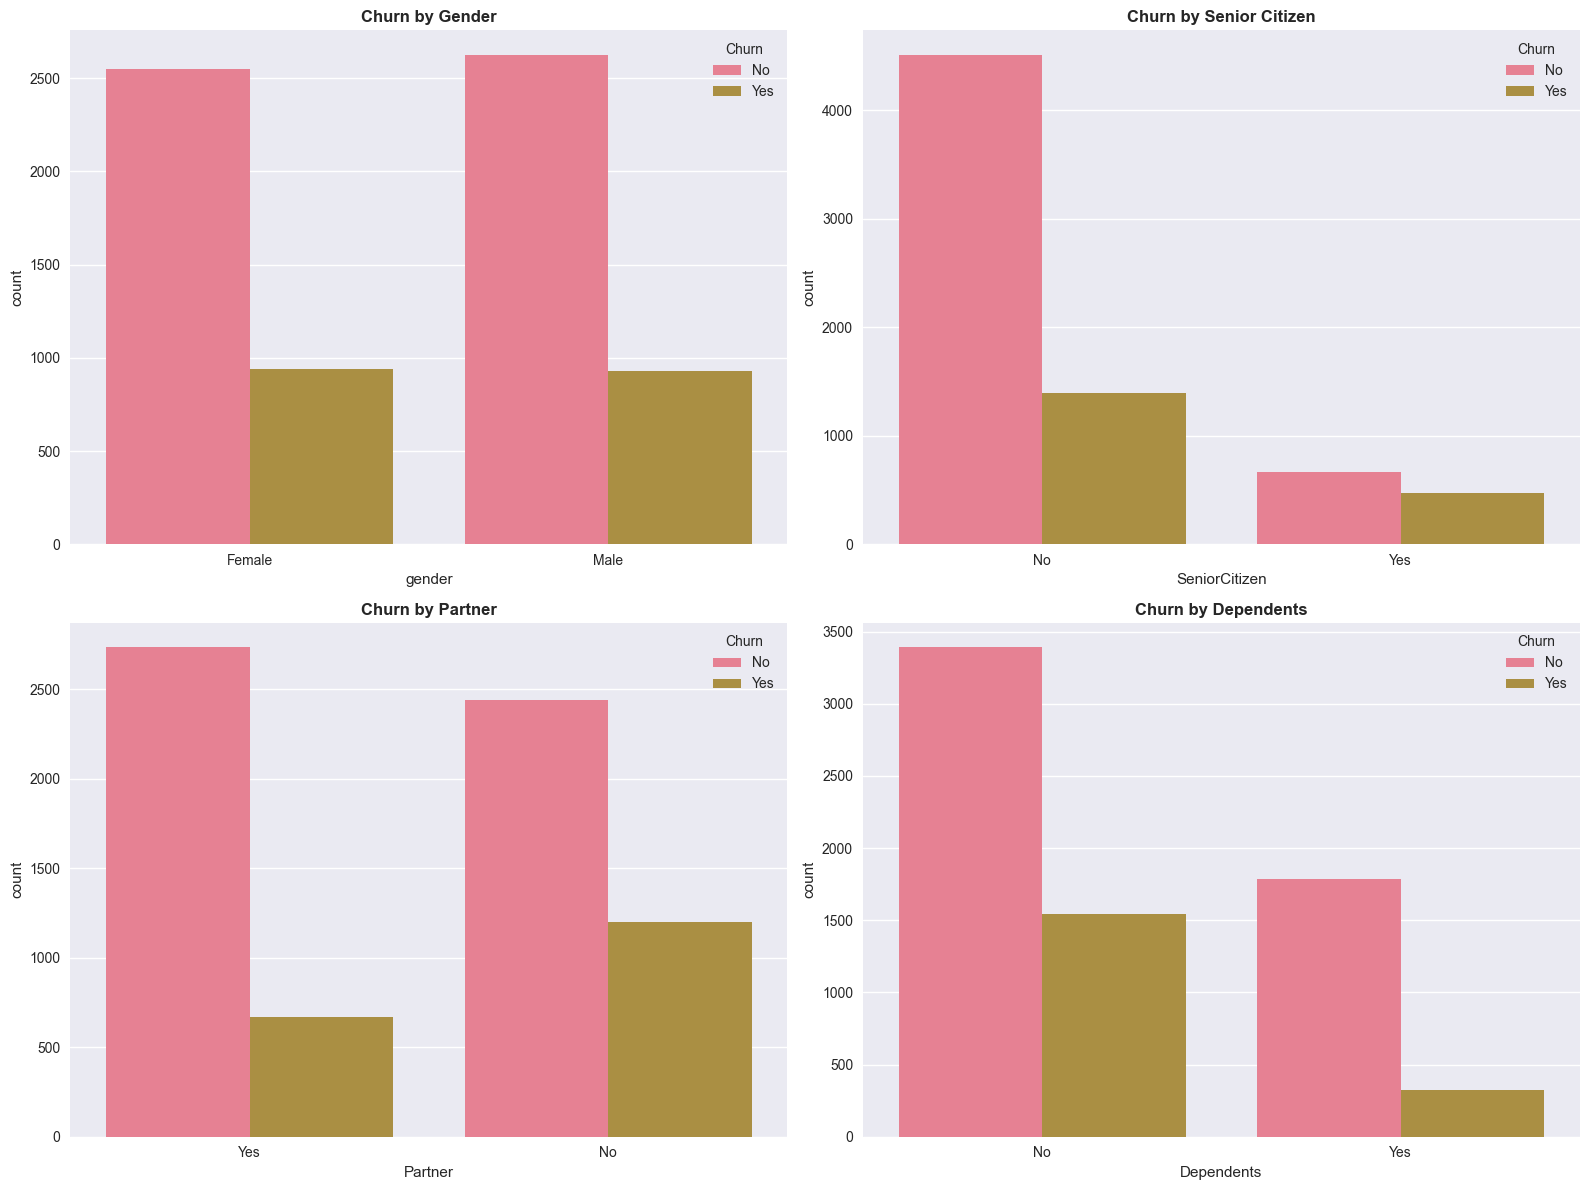

C:\Users\caida\AppData\Local\Temp\ipykernel_1860\4038556610.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby(['tenure_bucket', 'Churn']).size().unstack()


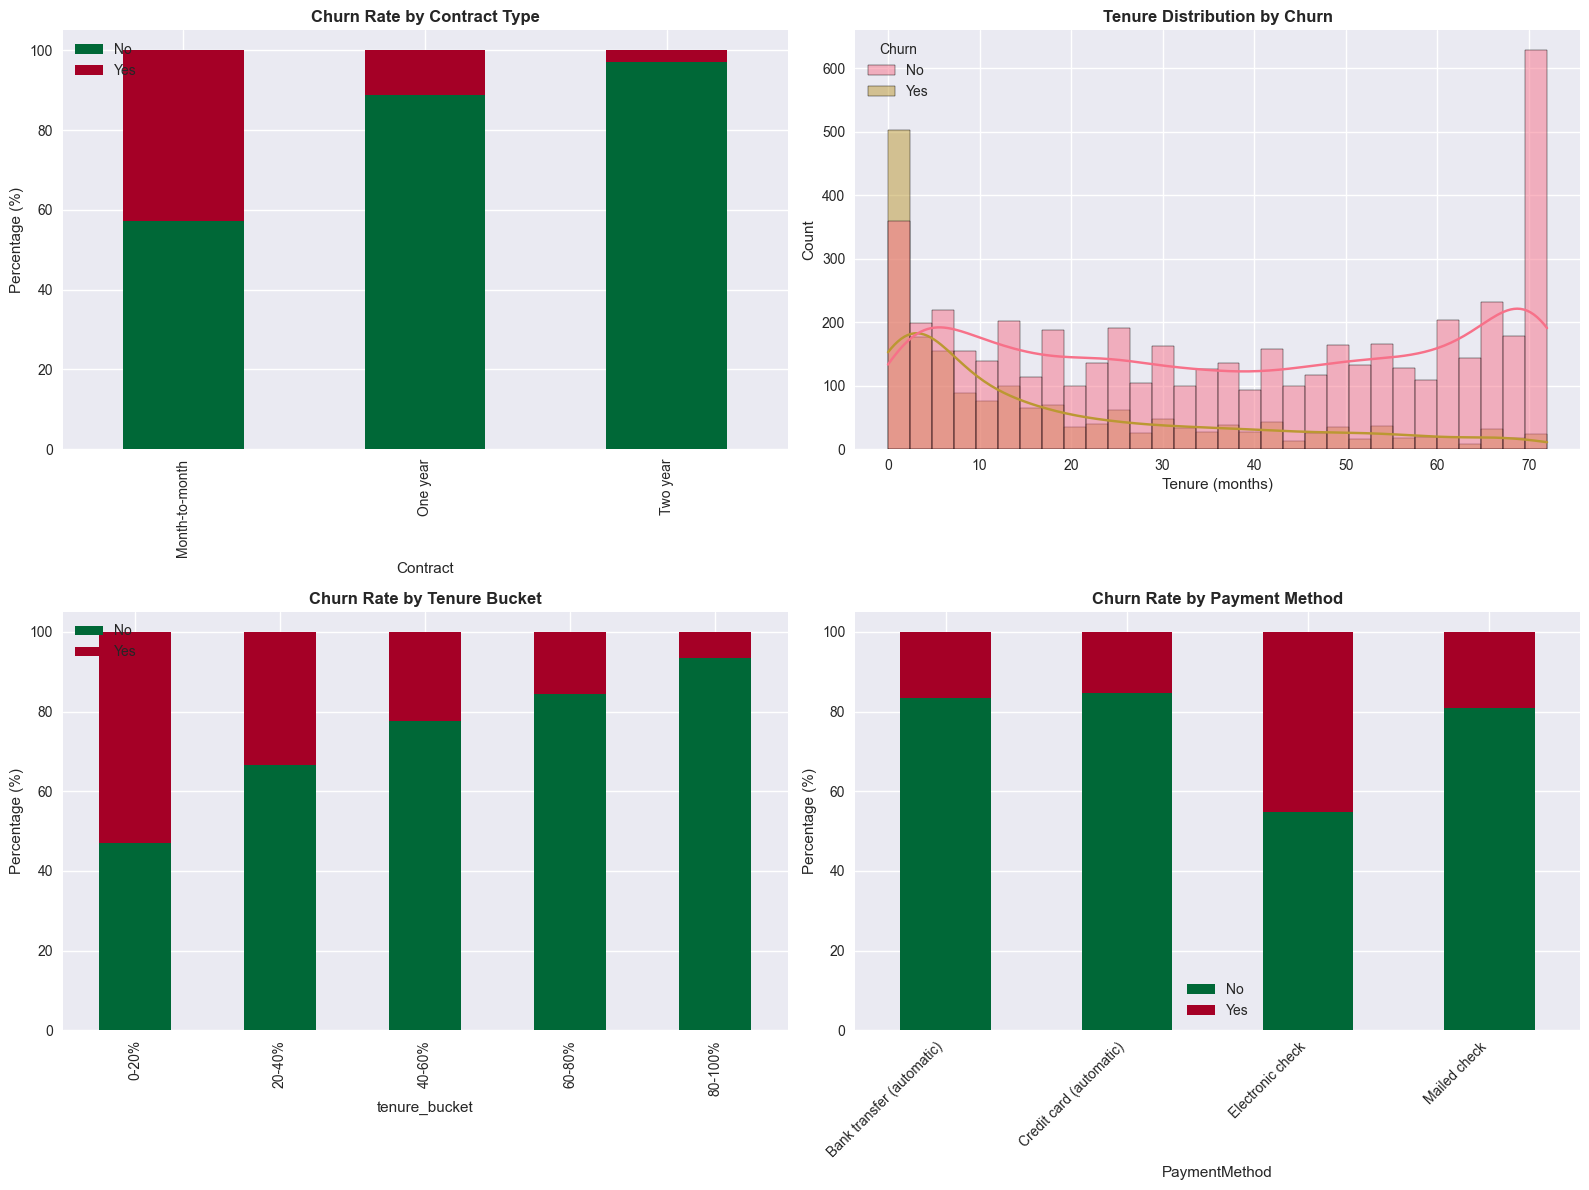

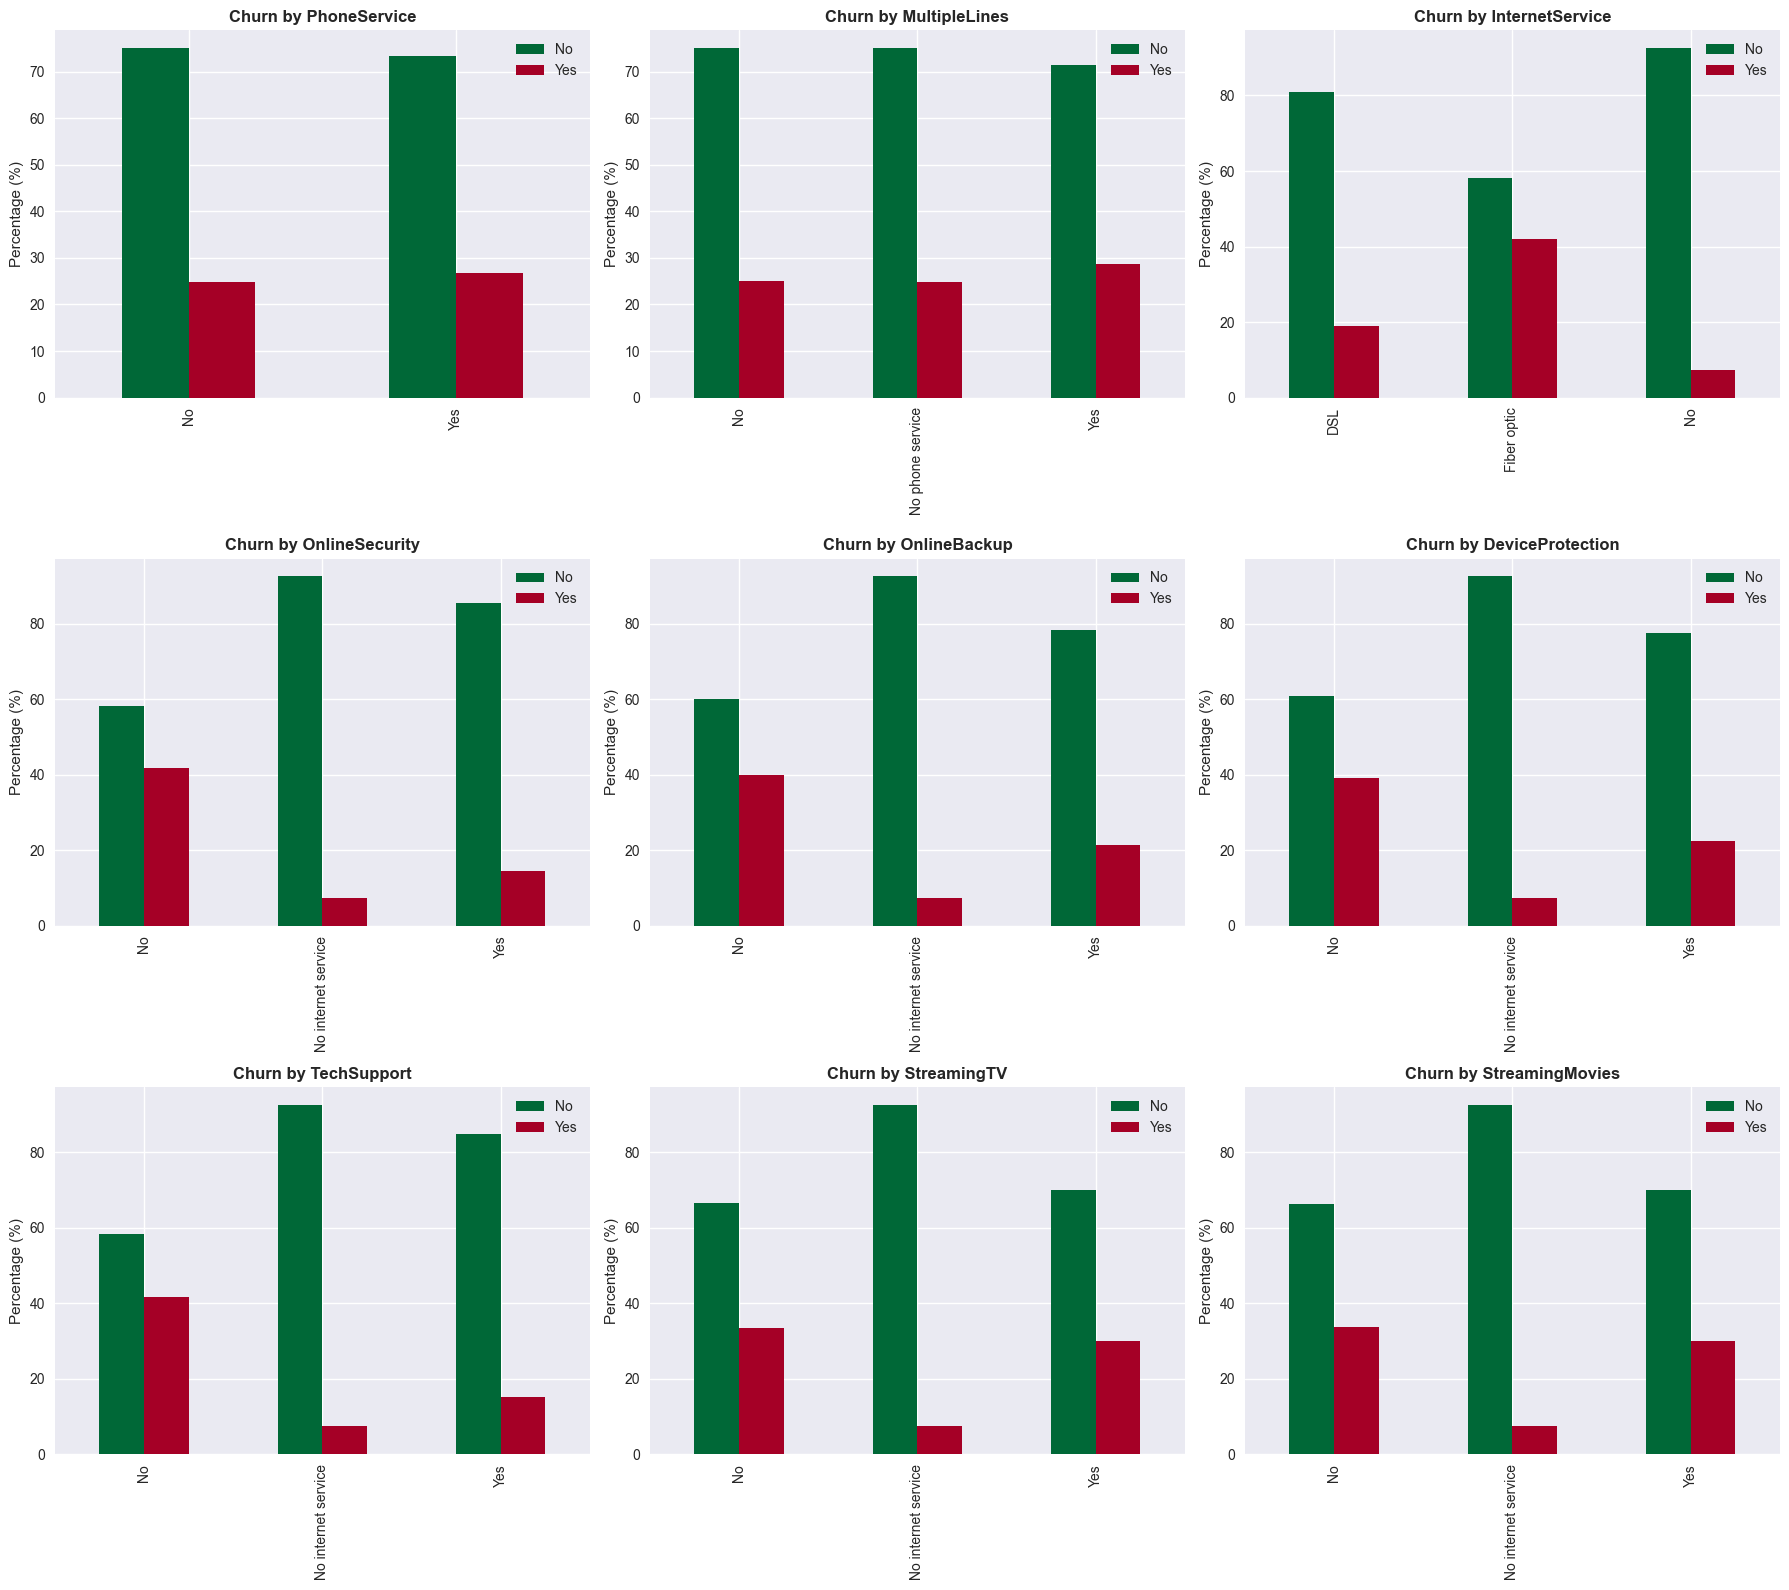

C:\Users\caida\AppData\Local\Temp\ipykernel_1860\4038556610.py:108: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('../reports/figures/charges_analysis.png', dpi=300, bbox_inches='tight')
d:\VT\Telecom-Customer-Churn-Prediction-using-Machine-Learning\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


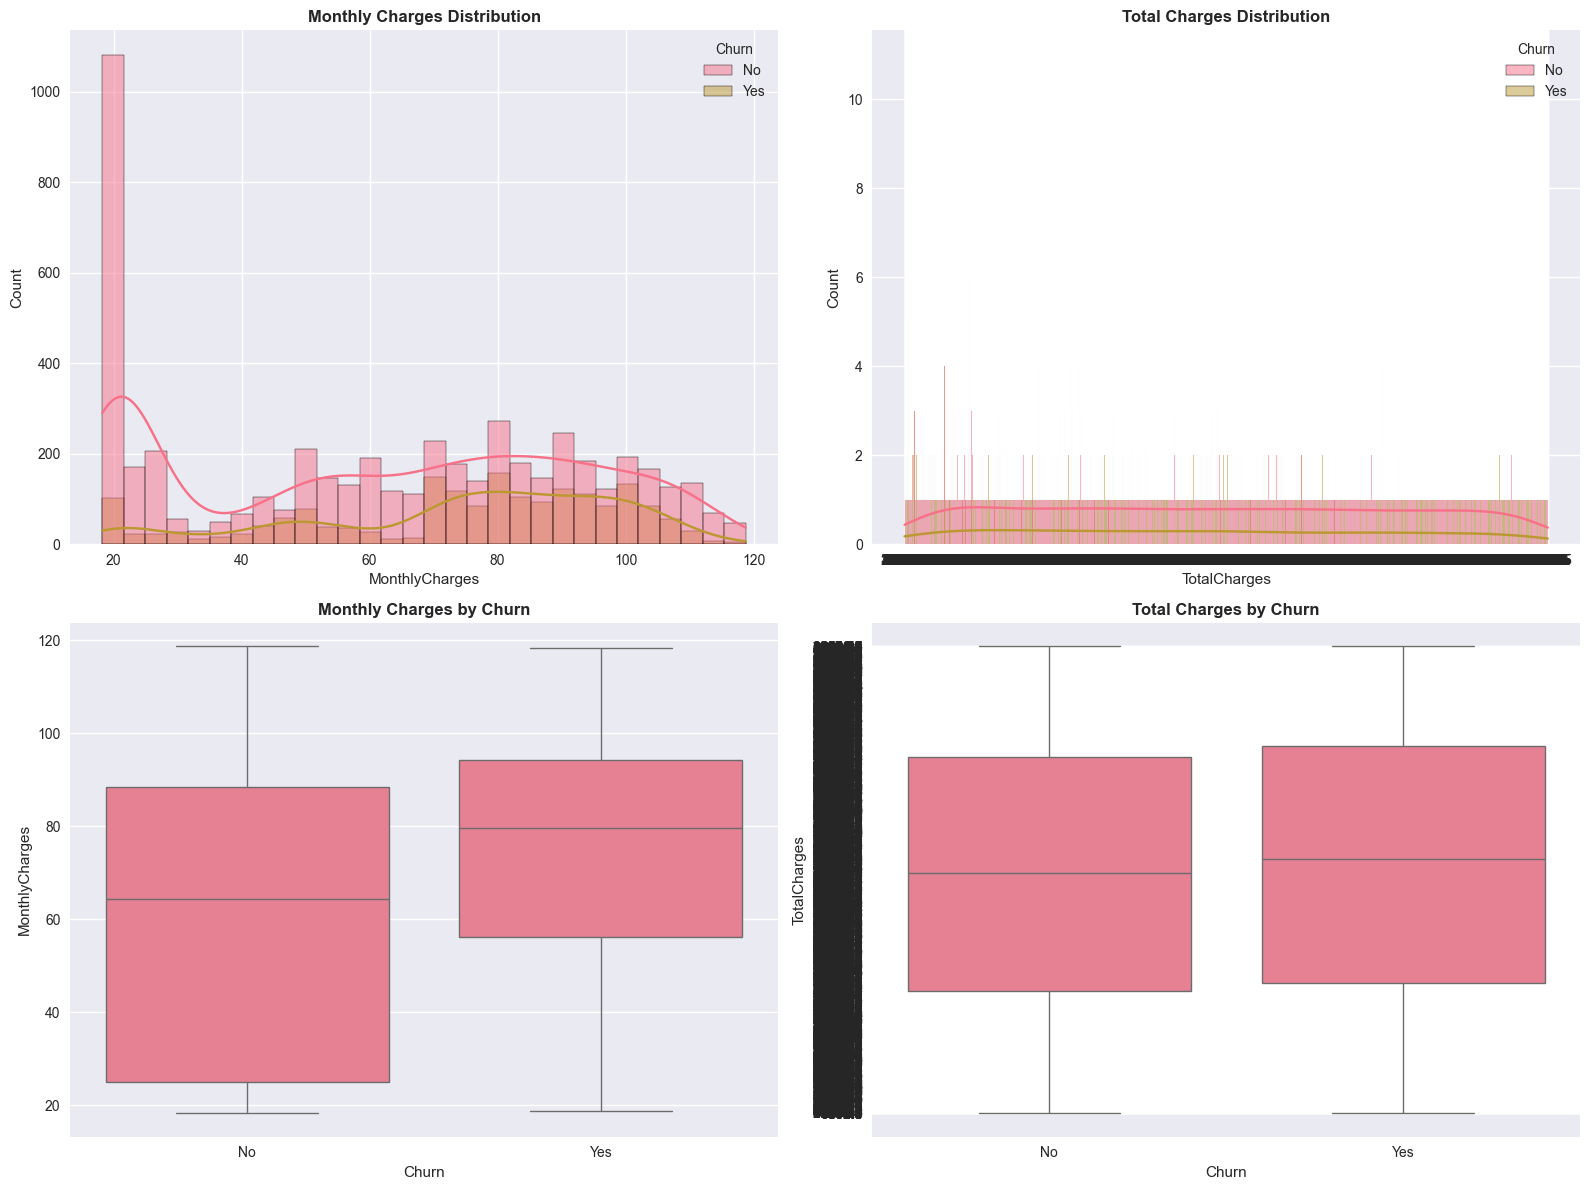

In [8]:
# Demographic analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gender
sns.countplot(data=df, x='gender', hue='Churn', ax=axes[0, 0])
axes[0, 0].set_title('Churn by Gender', fontweight='bold')

# Senior Citizen
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0, 1])
axes[0, 1].set_title('Churn by Senior Citizen', fontweight='bold')
axes[0, 1].set_xticklabels(['No', 'Yes'])

# Partner
sns.countplot(data=df, x='Partner', hue='Churn', ax=axes[1, 0])
axes[1, 0].set_title('Churn by Partner', fontweight='bold')

# Dependents
sns.countplot(data=df, x='Dependents', hue='Churn', ax=axes[1, 1])
axes[1, 1].set_title('Churn by Dependents', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/demographic_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Contract and tenure analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Contract type
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0) * 100

contract_churn_pct.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='RdYlGn_r')
axes[0, 0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].legend(['No', 'Yes'])

# Tenure distribution
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0, 1].set_xlabel('Tenure (months)')

# Tenure buckets
df['tenure_bucket'] = pd.qcut(df['tenure'], q=5, labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%'])
tenure_churn = df.groupby(['tenure_bucket', 'Churn']).size().unstack()
tenure_churn_pct = tenure_churn.div(tenure_churn.sum(axis=1), axis=0) * 100

tenure_churn_pct.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='RdYlGn_r')
axes[1, 0].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].legend(['No', 'Yes'])

# Payment method
payment_churn = df.groupby(['PaymentMethod', 'Churn']).size().unstack()
payment_churn_pct = payment_churn.div(payment_churn.sum(axis=1), axis=0) * 100

payment_churn_pct.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='RdYlGn_r')
axes[1, 1].set_title('Churn Rate by Payment Method', fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].legend(['No', 'Yes'])
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../reports/figures/contract_tenure_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Services analysis
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

for i, service in enumerate(services):
    if service in df.columns:
        service_churn = df.groupby([service, 'Churn']).size().unstack()
        service_churn_pct = service_churn.div(service_churn.sum(axis=1), axis=0) * 100
        
        service_churn_pct.plot(kind='bar', ax=axes[i], colormap='RdYlGn_r')
        axes[i].set_title(f'Churn by {service}', fontweight='bold')
        axes[i].set_ylabel('Percentage (%)')
        axes[i].legend(['No', 'Yes'])
        axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../reports/figures/services_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Charges analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Monthly charges distribution
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Monthly Charges Distribution', fontweight='bold')

# Total charges distribution
sns.histplot(data=df, x='TotalCharges', hue='Churn', bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Total Charges Distribution', fontweight='bold')

# Monthly charges by churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1, 0])
axes[1, 0].set_title('Monthly Charges by Churn', fontweight='bold')

# Total charges by churn
sns.boxplot(data=df, x='Churn', y='TotalCharges', ax=axes[1, 1])
axes[1, 1].set_title('Total Charges by Churn', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/charges_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


# Correlation analysis


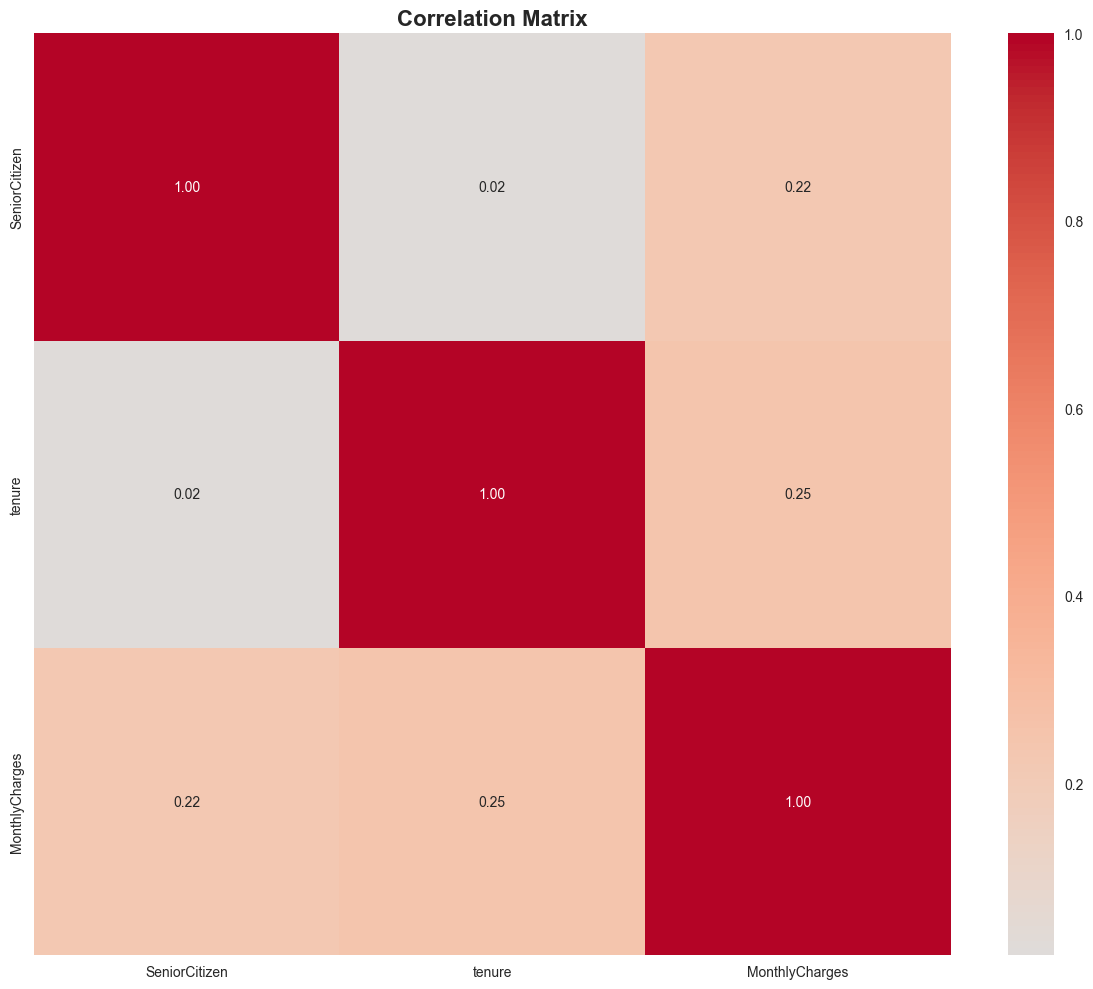

In [9]:
# Correlation analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()



# Statistical significance testing


Statistical Significance Tests:

Monthly Charges T-test:
  T-statistic: 16.5367
  P-value: 0.0000
  Significant: Yes

Contract Type Chi-square test:
  Chi-square: 1184.5966
  P-value: 0.0000
  Significant: Yes


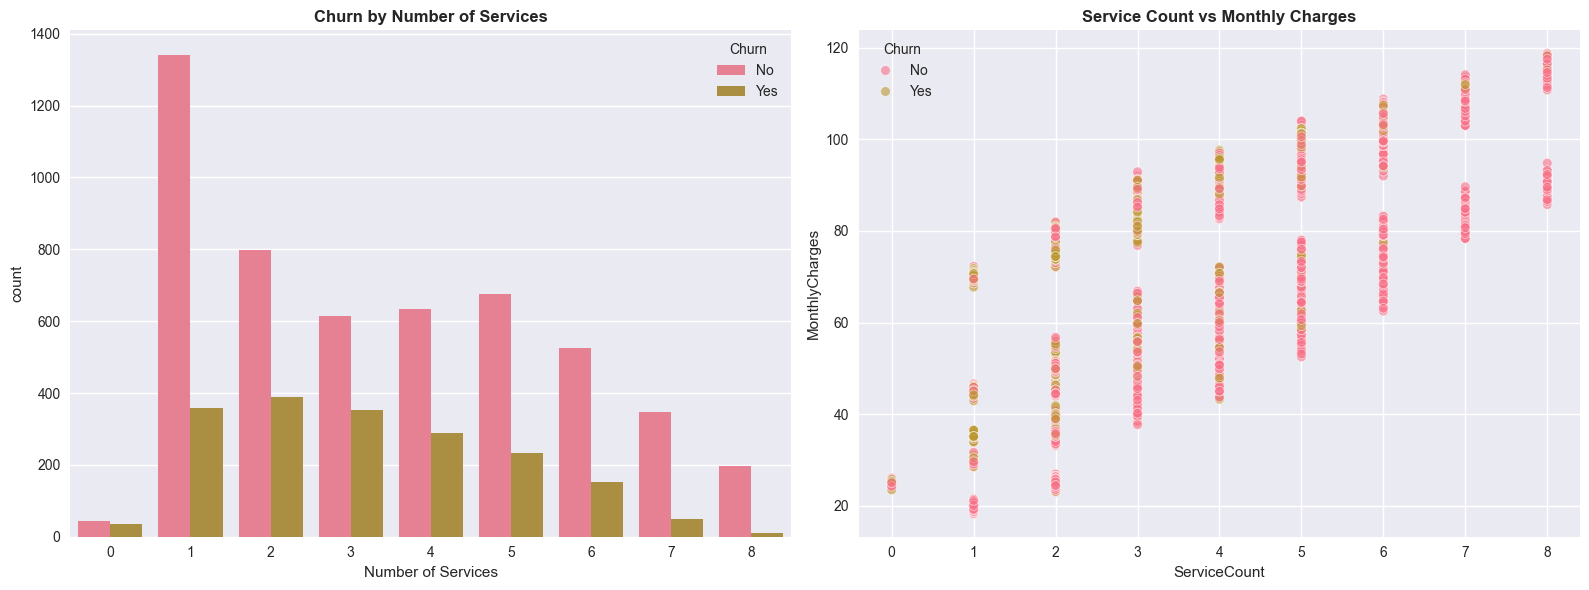

In [10]:
from scipy import stats

print("Statistical Significance Tests:")
print("=" * 60)

# T-test for monthly charges
churn_yes = df[df['Churn'] == 'Yes']['MonthlyCharges']
churn_no = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_value = stats.ttest_ind(churn_yes, churn_no)
print(f"\nMonthly Charges T-test:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")

# Chi-square test for contract type
contingency_table = pd.crosstab(df['Contract'], df['Churn'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nContract Type Chi-square test:")
print(f"  Chi-square: {chi2:.4f}")
print(f"  P-value: {p_value:.4f}")
print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")

# %%
# Customer segmentation analysis
df['ServiceCount'] = df[services].apply(lambda x: x.str.contains('Yes').sum(), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Service count distribution
sns.countplot(data=df, x='ServiceCount', hue='Churn', ax=axes[0])
axes[0].set_title('Churn by Number of Services', fontweight='bold')
axes[0].set_xlabel('Number of Services')

# Service count vs monthly charges
sns.scatterplot(data=df, x='ServiceCount', y='MonthlyCharges', hue='Churn', alpha=0.6, ax=axes[1])
axes[1].set_title('Service Count vs Monthly Charges', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/customer_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()



# Key insights summary


In [11]:
print("=" * 80)
print("KEY INSIGHTS FROM EDA")
print("=" * 80)

print(f"\n1. Overall Churn Rate: {churn_pct[1]:.2f}%")
print(f"2. Contract Type Impact:")
contract_summary = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
for contract, rate in contract_summary.items():
    print(f"   - {contract}: {rate:.2f}% churn rate")

print(f"\n3. Tenure Impact:")
tenure_summary = df.groupby('tenure_bucket')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
for bucket, rate in tenure_summary.items():
    print(f"   - {bucket} tenure: {rate:.2f}% churn rate")

print(f"\n4. Payment Method Impact:")
payment_summary = df.groupby('PaymentMethod')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
for method, rate in payment_summary.items():
    print(f"   - {method}: {rate:.2f}% churn rate")

print(f"\n5. Monthly Charges:")
print(f"   - Churn customers avg: ${churn_yes.mean():.2f}")
print(f"   - Non-churn customers avg: ${churn_no.mean():.2f}")
print(f"   - Difference: ${abs(churn_yes.mean() - churn_no.mean()):.2f}")

print("\n" + "=" * 80)


KEY INSIGHTS FROM EDA

1. Overall Churn Rate: 26.54%
2. Contract Type Impact:
   - Month-to-month: 42.71% churn rate
   - One year: 11.27% churn rate
   - Two year: 2.83% churn rate

3. Tenure Impact:
   - 0-20% tenure: 52.94% churn rate
   - 20-40% tenure: 33.43% churn rate
   - 40-60% tenure: 22.37% churn rate
   - 60-80% tenure: 15.56% churn rate
   - 80-100% tenure: 6.61% churn rate

4. Payment Method Impact:
   - Bank transfer (automatic): 16.71% churn rate
   - Credit card (automatic): 15.24% churn rate
   - Electronic check: 45.29% churn rate
   - Mailed check: 19.11% churn rate

5. Monthly Charges:
   - Churn customers avg: $74.44
   - Non-churn customers avg: $61.27
   - Difference: $13.18



C:\Users\caida\AppData\Local\Temp\ipykernel_1860\4036492330.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"\n1. Overall Churn Rate: {churn_pct[1]:.2f}%")
C:\Users\caida\AppData\Local\Temp\ipykernel_1860\4036492330.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_summary = df.groupby('tenure_bucket')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)




# Save processed data for next steps

In [12]:

df.to_csv('../data/processed/eda_completed.csv', index=False)
print("\n EDA completed and saved to ../data/processed/eda_completed.csv")


 EDA completed and saved to ../data/processed/eda_completed.csv
